# From one prediction to an LLM behavioral model

**Progressive hands-on notebook / DeepSeek API / anonymized individual-level risky-choice data**

We will reuse one measurement all the way through:

1. hide one participant's choice;
2. ask the model to predict **A or B**;
3. inspect the model's top-token **log probabilities**;
4. re-normalize probability mass over the valid labels `{A, B}`;
5. reveal the human choice and compute log loss;
6. repeat while increasing the number of earlier choices in context.

The last step turns a vivid example into a behavioral-model evaluation. More examples are a hypothesis, not a guarantee of improvement.

## 0. Setup

The notebook runs on Colab or an ordinary laptop because inference is an API call. Put `DEEPSEEK_API_KEY=...` in the project `.env`, set it as an environment variable, or add it to Colab Secrets. The notebook never prints the key.

In [1]:
# Uncomment in a fresh Colab runtime.
# %pip install -q openai pandas numpy matplotlib scikit-learn

In [2]:
from pathlib import Path
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openai import OpenAI

MODEL = "deepseek-v4-flash"
BASE_URL = "https://api.deepseek.com"
SEED = 3000
pd.set_option("display.max_colwidth", 110)
plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
def find_file(relative_path):
    relative_path = Path(relative_path)
    candidates = [
        relative_path,
        Path("notebooks") / relative_path,
        Path("/content") / relative_path,
        Path("/content/LLM_human_decisions/notebooks") / relative_path,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {relative_path}")


def load_dotenv_without_extra_package():
    candidates = [Path(".env"), Path("../.env"), Path("../../.env")]
    for path in candidates:
        if path.exists():
            for line in path.read_text(encoding="utf-8").splitlines():
                line = line.strip()
                if line and not line.startswith("#") and "=" in line:
                    key, value = line.split("=", 1)
                    os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))
            return path
    return None


env_path = load_dotenv_without_extra_package()
api_key = os.getenv("DEEPSEEK_API_KEY")
client = OpenAI(api_key=api_key, base_url=BASE_URL) if api_key else None
print("DeepSeek key available:", bool(api_key))
print("Loaded .env from:", env_path if env_path else "environment / Colab secret / not found")

DeepSeek key available: False
Loaded .env from: environment / Colab secret / not found


In [4]:
DATA_PATH = find_file("data/behavioral_expanded_public_slice.csv")
data = pd.read_csv(DATA_PATH)

assert data["participant_id"].nunique() == 32
assert data.groupby("participant_id").size().eq(40).all()
assert set(data["choice"]) <= {"A", "B"}

print(f"Loaded {len(data):,} rows: {data['participant_id'].nunique()} participants x 40 ordered trials")
print("Public slice excludes raw IDs, language, RT, and other unnecessary fields.")

Loaded 1,280 rows: 32 participants x 40 ordered trials
Public slice excludes raw IDs, language, RT, and other unnecessary fields.


## 1. Begin with one real held-out choice

We use anonymized participant `P025`, trial 21. Trials 1-20 are earlier in time and therefore eligible as history; the target choice stays hidden until scoring.

In [5]:
participant_id = "P025"
target_trial = 21
target = data.query(
    "participant_id == @participant_id and trial_index == @target_trial"
).iloc[0]

print("Participant screen")
print("------------------")
print("Option A:", target["lottery_A"])
print("Option B:", target["lottery_B"])
print("Observed choice: [HIDDEN]")

Participant screen
------------------
Option A: 75% chance of -16; 25% chance of 40
Option B: -3 for sure
Observed choice: [HIDDEN]


In [6]:
def make_messages(target_row, history=None):
    history = history if history is not None else pd.DataFrame()
    history_text = ""
    if len(history):
        examples = []
        for _, row in history.iterrows():
            examples.append(
                f"Earlier trial {int(row['trial_index'])}:\n"
                f"Option A: {row['lottery_A']}\n"
                f"Option B: {row['lottery_B']}\n"
                f"Observed choice: {row['choice']}"
            )
        history_text = (
            "Here are earlier choices from the same participant:\n\n"
            + "\n\n".join(examples)
            + "\n\n"
        )

    return [
        {"role": "system", "content": "Answer with exactly one token: A or B."},
        {
            "role": "user",
            "content": (
                history_text
                + "Predict this participant's choice on a new trial.\n"
                + f"Option A: {target_row['lottery_A']}\n"
                + f"Option B: {target_row['lottery_B']}\n"
                + "Answer:"
            ),
        },
    ]


zero_shot_messages = make_messages(target)
print(zero_shot_messages[1]["content"])

Predict this participant's choice on a new trial.
Option A: 75% chance of -16; 25% chance of 40
Option B: -3 for sure
Answer:


## 2. Ask for the label *and* top-token logprobs

Set `temperature=1` so the returned logprobs stay on the model's natural scale. The generated `A` or `B` is one sample; the probability estimate comes from the candidate-label logprobs.

DeepSeek returns logprobs for token surface forms. `"A"` and `" A"` can be different tokens, even though both mean label A after whitespace normalization.

In [7]:
def call_label_logprobs(messages):
    if client is None:
        raise RuntimeError("Set DEEPSEEK_API_KEY before making a live call.")
    return client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=1,
        max_tokens=1,
        logprobs=True,
        top_logprobs=20,
        extra_body={"thinking": {"type": "disabled"}},
    )


def logsumexp(values):
    peak = max(values)
    return peak + math.log(sum(math.exp(value - peak) for value in values))


def extract_choice_probability(response):
    items = response.choices[0].logprobs.content[0].top_logprobs
    groups = {"A": [], "B": []}
    rows = []
    for item in items:
        rows.append({"token": repr(item.token), "logprob": float(item.logprob)})
        label = item.token.strip()
        if label in groups:
            groups[label].append(float(item.logprob))

    if not groups["A"] or not groups["B"]:
        raise ValueError("Increase top_logprobs: A and B must both be observed.")

    label_lp = {label: logsumexp(values) for label, values in groups.items()}
    log_z = logsumexp(list(label_lp.values()))
    probabilities = {label: math.exp(lp - log_z) for label, lp in label_lp.items()}
    return pd.DataFrame(rows), groups, label_lp, probabilities

In [8]:
RUN_SINGLE_API = False  # Change to True for a fresh live call (one charged request).

if RUN_SINGLE_API:
    single_response = call_label_logprobs(zero_shot_messages)
    top_tokens, surface_forms, label_lp, choice_probability = extract_choice_probability(single_response)
    sampled_output = single_response.choices[0].message.content
else:
    DETAILS_PATH = find_file("results/deepseek_history_curve_pilot.jsonl")
    cached = json.loads(DETAILS_PATH.read_text(encoding="utf-8").splitlines()[0])
    top_tokens = pd.DataFrame(cached["top_logprobs"][:10])
    top_tokens["token"] = top_tokens["token"].map(repr)
    surface_forms = cached["surface_forms"]
    label_lp = cached["label_logprob"]
    choice_probability = {"A": 1 - cached["p_B"], "B": cached["p_B"]}
    sampled_output = cached["sampled_output"]

print("Generated sample:", sampled_output)
display(top_tokens.head(10))
print("Label surface forms:", surface_forms)
print("Aggregated label logprobs:", {k: round(v, 3) for k, v in label_lp.items()})
print("Re-normalized P(A), P(B):", {k: round(v, 3) for k, v in choice_probability.items()})

Generated sample: B


,token,logprob
0,'B',-0.288625
1,'A',-1.383481
2,'Based',-14.395160
3,'The',-14.959966
4,'Let',-15.219514
5,' B',-15.284223
6,'Option',-15.840257
7,'Since',-16.150127
8,' A',-16.229263
9,'I',-16.388912


Label surface forms: {'A': [-1.3834813, -16.229263], 'B': [-0.288625, -15.284223]}
Aggregated label logprobs: {'A': -1.383, 'B': -0.289}
Re-normalized P(A), P(B): {'A': 0.251, 'B': 0.749}


**Why aggregate instead of overwrite?** A dictionary comprehension such as `{token.strip(): logprob}` silently keeps only the final surface form. If both `"A"` and `" A"` appear, it discards probability mass and may change the result. We aggregate with log-sum-exp, then normalize over the declared choice set.

## 3. Reveal the human choice and compute loss

For observed choice \(y\), single-trial negative log likelihood is

\[
\mathcal{L} = -\log p(y).
\]

Accuracy only asks which label had more mass. Log loss also rewards calibrated confidence and strongly penalizes confident errors.

In [9]:
observed = target["choice"]
predicted = max(choice_probability, key=choice_probability.get)
probability_observed = choice_probability[observed]
single_log_loss = -math.log(max(probability_observed, 1e-12))

print("Observed human choice:", observed)
print("Model prediction (argmax over A/B):", predicted)
print(f"Probability assigned to the observed choice: {probability_observed:.3f}")
print(f"Single-trial log loss: {single_log_loss:.3f}")

Observed human choice: B
Model prediction (argmax over A/B): B
Probability assigned to the observed choice: 0.749
Single-trial log loss: 0.289


## 4. Optional: inspect a generated reasoning trace

A reasoning trace can help audit what the model says it considered, and it may suggest ablations. It is **not** direct evidence of the participant's reasoning or a faithful readout of the model's causal mechanism.

In [10]:
RUN_REASONING_API = False  # Optional: one additional charged request.

if RUN_REASONING_API:
    reasoning_messages = [
        {
            "role": "user",
            "content": (
                "Predict the participant's choice and analyze the risky options. "
                "Finish with exactly 'Final: A' or 'Final: B'.\n"
                f"Option A: {target['lottery_A']}\n"
                f"Option B: {target['lottery_B']}"
            ),
        }
    ]
    response = client.chat.completions.create(
        model=MODEL,
        messages=reasoning_messages,
        temperature=1,
        max_tokens=1500,
        extra_body={"thinking": {"type": "enabled"}},
    )
    message = response.choices[0].message
    reasoning_trace = getattr(message, "reasoning_content", "[not returned]")
    final_response = message.content
else:
    REASONING_PATH = find_file("results/deepseek_reasoning_example.json")
    cached_reasoning = json.loads(REASONING_PATH.read_text(encoding="utf-8"))
    reasoning_trace = cached_reasoning.get("reasoning_content") or "[not returned]"
    final_response = cached_reasoning.get("content")

print("Reasoning excerpt:\n", reasoning_trace[:900])
print("\nFinal response:\n", final_response or "[No final label before the reasoning token budget ended]")

Reasoning excerpt:
 We are given two options: Option A is a gamble with 75% chance of -16 and 25% chance of 40. Option B is a sure loss of -3. We need to predict the participant's choice and analyze risky options. The participant is presumably a typical decision-maker under risk. We need to consider expected value and possibly risk aversion.

First, compute expected value (EV) of Option A: EV = 0.75*(-16) + 0.25*40 = -12 + 10 = -2. So Option A has an expected value of -2. Option B is a sure -3. So in terms of expected value, Option A is better (since -2 > -3). However, Option A involves risk, while Option B is certain loss. A risk-averse participant might prefer the sure thing if the gamble is too risky. But here the sure loss is worse in expected value. So a risk-neutral participant would choose A. But we need to consider prospect theory or typical behavior? The problem says "predict the participant's choi

Final response:
 [No final label before the reasoning token budget ended]


## 5. Move from one example to a learning curve

Now keep the model, prompt template, targets, and score fixed. Change only the number of **earlier trials from the same participant**:

\[
k \in \{0, 1, 2, 5, 10, 20\}.
\]

The scientific question is not "can we put more examples in the prompt?" It is: **does additional within-person evidence improve held-out prediction, and where does the gain saturate?**

In [11]:
participant_ids = sorted(data["participant_id"].unique())
TRAIN_PARTICIPANTS = participant_ids[:20]
VALID_PARTICIPANTS = participant_ids[20:24]
TEST_PARTICIPANTS = participant_ids[24:]

HISTORY_LENGTHS = [0, 1, 2, 5, 10, 20]
PILOT_PARTICIPANTS = ["P025", "P026"]
PILOT_TARGET_TRIALS = [21, 22, 23, 24]

split = pd.DataFrame({
    "role": ["task/SFT training", "model selection", "ICL history", "held-out evaluation"],
    "participants": ["P001-P020", "P021-P024", "P025-P032", "P025-P032"],
    "trials": ["1-40", "1-40", "1-20", "21-40"],
})
split

,role,participants,trials
0,task/SFT training,P001-P020,1-40
1,model selection,P021-P024,1-40
2,ICL history,P025-P032,1-20
3,held-out evaluation,P025-P032,21-40


In [12]:
def evaluate_response(response, observed_choice):
    _, _, _, probabilities = extract_choice_probability(response)
    p_b = probabilities["B"]
    y = int(observed_choice == "B")
    return {
        "p_B": p_b,
        "predicted_choice": "B" if p_b >= 0.5 else "A",
        "correct": int((p_b >= 0.5) == bool(y)),
        "log_loss": -(y * math.log(max(p_b, 1e-12)) + (1-y) * math.log(max(1-p_b, 1e-12))),
        "brier": (p_b-y) ** 2,
    }


def run_curve(participants, target_trials, history_lengths):
    rows = []
    for participant in participants:
        person = data[data["participant_id"] == participant].sort_values("trial_index")
        history_pool = person[person["trial_index"] <= 20]
        for target_trial in target_trials:
            target_row = person[person["trial_index"] == target_trial].iloc[0]
            for k in history_lengths:
                history = history_pool.head(k)
                response = call_label_logprobs(make_messages(target_row, history))
                row = evaluate_response(response, target_row["choice"])
                rows.append({
                    "participant_id": participant,
                    "target_trial": target_trial,
                    "history_trials": k,
                    "actual_choice": target_row["choice"],
                    "prompt_tokens": response.usage.prompt_tokens,
                    **row,
                })
    return pd.DataFrame(rows)

In [13]:
RUN_CURVE_API = False  # The classroom default uses cached public results.

if RUN_CURVE_API:
    pilot_results = run_curve(
        PILOT_PARTICIPANTS, PILOT_TARGET_TRIALS, HISTORY_LENGTHS
    )
    pilot_results.to_csv("deepseek_history_curve_fresh.csv", index=False)
    curve = (
        pilot_results.groupby("history_trials", as_index=False)
        .agg(
            n=("correct", "size"),
            accuracy=("correct", "mean"),
            log_loss=("log_loss", "mean"),
            brier=("brier", "mean"),
            prompt_tokens=("prompt_tokens", "sum"),
        )
    )
else:
    SUMMARY_PATH = find_file("results/deepseek_history_curve_pilot_summary.csv")
    curve = pd.read_csv(SUMMARY_PATH)

curve.round(3)

,history_trials,n,accuracy,log_loss,brier,prompt_tokens
0,0,8,0.875,0.594,0.186,619
1,1,8,0.750,0.772,0.269,1167
2,2,8,0.625,0.692,0.248,1519
3,5,8,0.500,1.029,0.374,3139
4,10,8,0.375,1.684,0.526,5639
5,20,8,0.375,1.281,0.438,10007


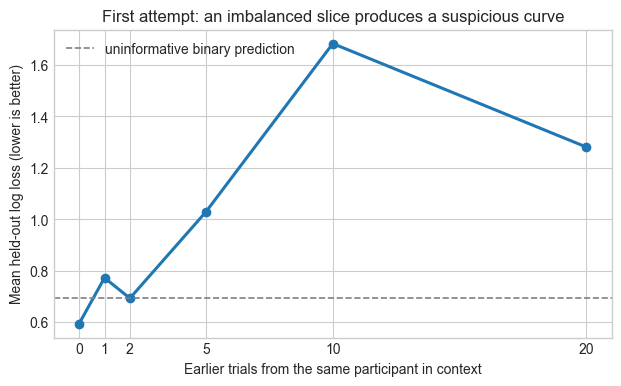

In [14]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(curve["history_trials"], curve["log_loss"], marker="o", linewidth=2.2)
ax.axhline(math.log(2), color="gray", linestyle="--", linewidth=1.2, label="uninformative binary prediction")
ax.set(
    title="First attempt: an imbalanced slice produces a suspicious curve",
    xlabel="Earlier trials from the same participant in context",
    ylabel="Mean held-out log loss (lower is better)",
    xticks=HISTORY_LENGTHS,
)
ax.legend(frameon=False)
plt.show()

### What this pilot says-and does not say

In this **pipeline check** (2 participants x 4 targets = 8 held-out choices), zero-shot was best; adding history eventually hurt. This is not evidence that ICL never works. It shows why history length must be treated as an experimentally manipulated variable and why a curve can reveal improvement, saturation, interference, or decline.

A formal experiment should add:

- all prespecified test participants and target trials;
- uncertainty intervals clustered or bootstrapped by participant;
- same-person versus other-person history;
- intact versus shuffled trial-choice links;
- prompt-order and A/B-position controls;
- transparent baselines such as response frequency and logistic regression.

## 6. Keep the failed first attempt-and diagnose it

The first pilot is pedagogically useful precisely because it is not a valid scaling result. Its targets contain **7 B and 1 A**, while the two participants' 20-trial histories contain **25 A and 15 B**. Increasing `k` therefore changes both the amount of evidence and the label distribution in context.

| Slice | A | B | B rate |
|---|---:|---:|---:|
| Original pilot targets | 1 | 7 | 87.5% |
| Original pilot history, k=20 | 25 | 15 | 37.5% |

This is the failure case to retain in teaching: an apparently interesting ICL curve can be produced by a simple balance mismatch.

## 7. Balance both history and targets, then extend k

To examine saturation more cleanly:

- use `P026`, `P028`, and `P031`, whose first 20 trials contain at least 9 A and 9 B;
- select 4 A and 4 B targets per participant: 24 held-out choices total;
- use `k = 0, 2, 4, ..., 18`;
- require every non-zero history to contain exactly `k/2` A and `k/2` B;
- make histories nested within each draw;
- repeat the balanced history selection with three seeds while holding targets fixed.

The error bars below are the standard deviation across the three history selections. They are **not** participant-level confidence intervals.

In [15]:
EXPANDED_PATH = find_file("results/expanded_balanced_summary.csv")
expanded = pd.read_csv(EXPANDED_PATH)
expanded[[
    "history_trials", "draws", "accuracy_mean", "accuracy_sd",
    "log_loss_mean", "log_loss_sd", "mean_p_B"
]].round(3)

,history_trials,draws,accuracy_mean,accuracy_sd,log_loss_mean,log_loss_sd,mean_p_B
0,0,1,0.500,NaN,0.878,NaN,0.751
1,2,3,0.542,0.042,0.794,0.047,0.418
2,4,3,0.583,0.110,0.816,0.145,0.406
3,6,3,0.528,0.087,0.818,0.130,0.429
4,8,3,0.528,0.064,0.873,0.138,0.460
5,10,3,0.597,0.024,0.944,0.076,0.380
6,12,3,0.569,0.087,0.911,0.112,0.381
7,14,3,0.583,0.000,0.959,0.223,0.365
8,16,3,0.542,0.042,0.861,0.119,0.395
9,18,3,0.611,0.024,0.916,0.033,0.349


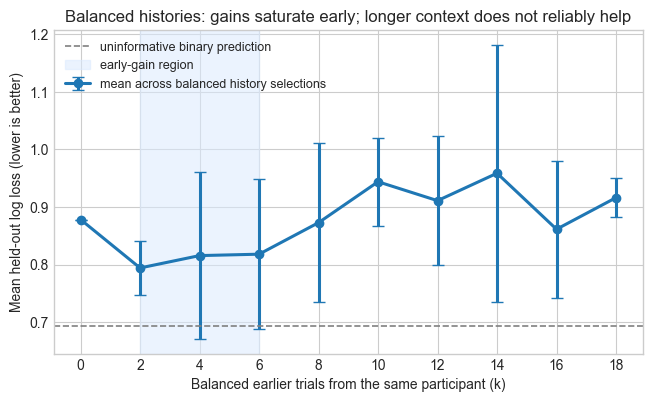

In [16]:
fig, ax = plt.subplots(figsize=(7.6, 4.2))
yerr = expanded["log_loss_sd"].fillna(0)
ax.errorbar(
    expanded["history_trials"], expanded["log_loss_mean"],
    yerr=yerr, marker="o", linewidth=2.2, capsize=4,
    label="mean across balanced history selections",
)
ax.axhline(math.log(2), color="gray", linestyle="--", linewidth=1.2,
           label="uninformative binary prediction")
ax.axvspan(2, 6, color="#dbeafe", alpha=0.55, label="early-gain region")
ax.set(
    title="Balanced histories: gains saturate early; longer context does not reliably help",
    xlabel="Balanced earlier trials from the same participant (k)",
    ylabel="Mean held-out log loss (lower is better)",
    xticks=expanded["history_trials"],
)
ax.legend(frameon=False, fontsize=9)
plt.show()

### Interpretation

Zero-shot log loss is `0.878`. Balanced history improves it to `0.794-0.818` for `k=2-6`. Beyond that range, additional examples do not produce a stable gain; mean log loss generally rises again.

That aggregate curve is useful, but it mixes participants whose trajectories point in different directions. Before concluding that ICL simply "plateaus," inspect participant-level curves.

In [ ]:
DETAILS_PATH = find_file(
    "results/expanded_balanced_combined/expanded_balanced_details.csv"
)
expanded_details = pd.read_csv(DETAILS_PATH)

participant_curve = (
    expanded_details
    .groupby(["participant_id", "history_trials"], as_index=False)
    .agg(
        n_predictions=("correct", "size"),
        accuracy=("correct", "mean"),
        log_loss=("log_loss", "mean"),
    )
)

# k=0 contains 8 targets per participant. For k>0, each point combines
# the same 8 targets across 3 independently selected balanced histories.
participant_curve.round(3)

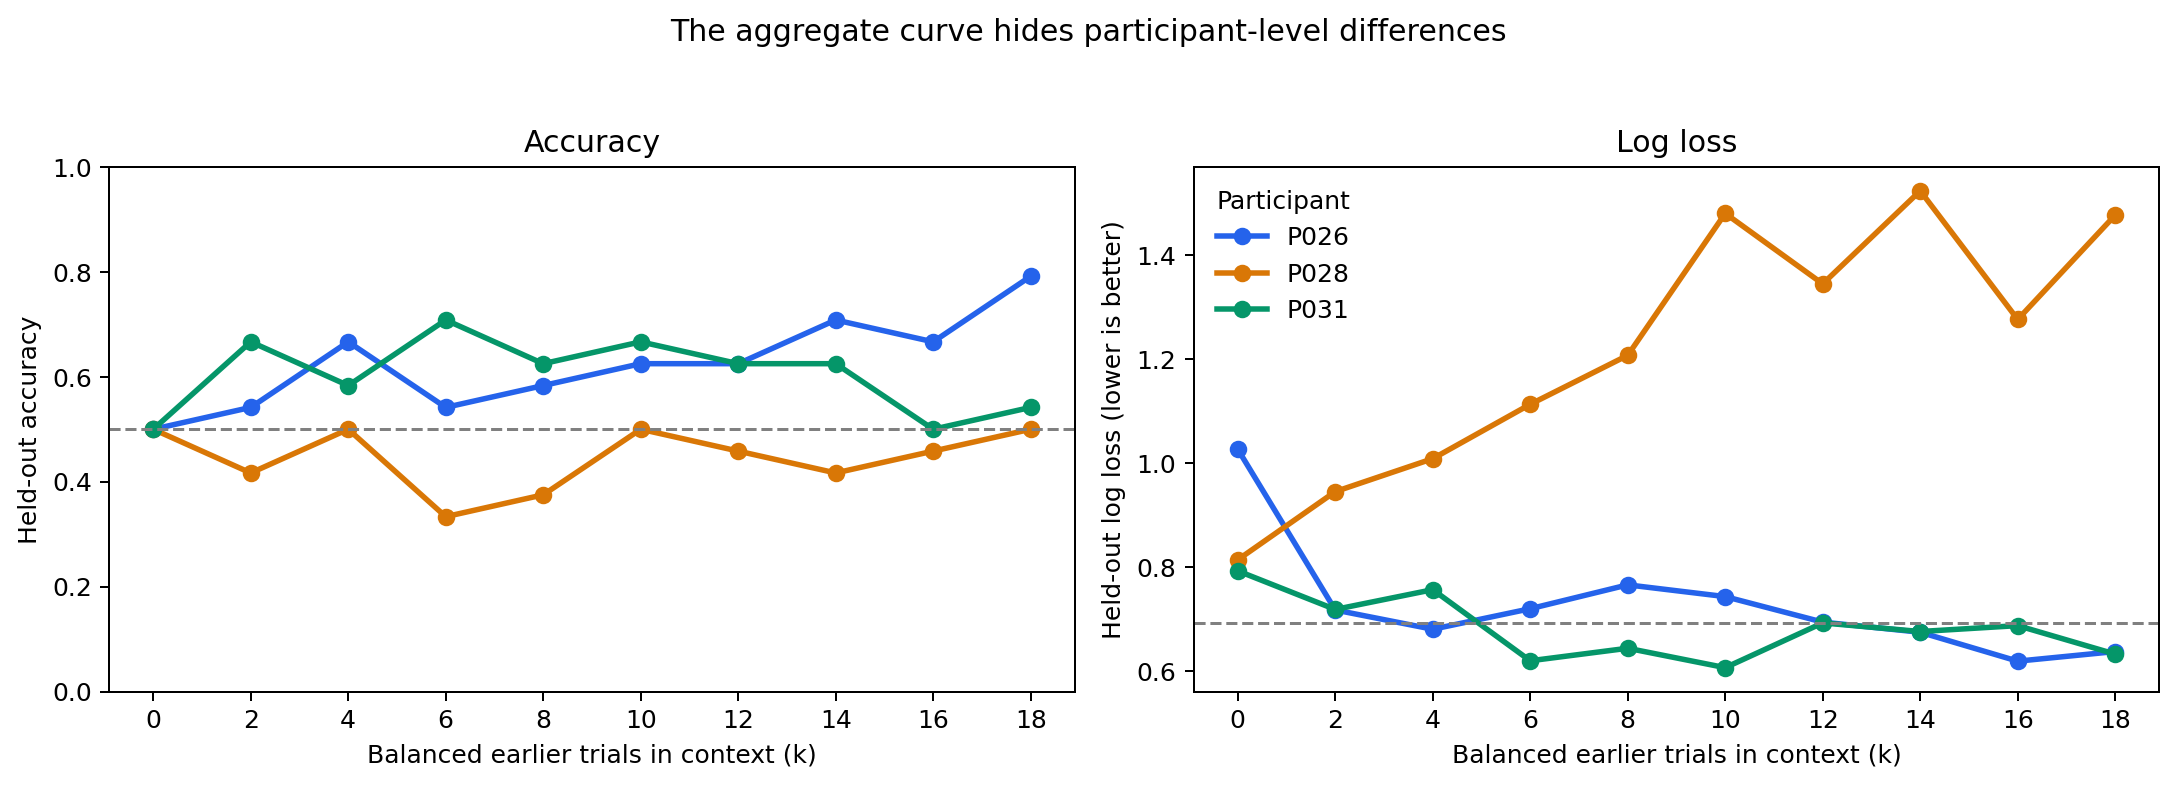

In [ ]:
colors = {"P026": "#2563eb", "P028": "#d97706", "P031": "#059669"}
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.2), sharex=True)

for participant, group in participant_curve.groupby("participant_id"):
    group = group.sort_values("history_trials")
    axes[0].plot(
        group["history_trials"], group["accuracy"],
        marker="o", linewidth=2.2, label=participant,
        color=colors[participant],
    )
    axes[1].plot(
        group["history_trials"], group["log_loss"],
        marker="o", linewidth=2.2, label=participant,
        color=colors[participant],
    )

axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=1.2)
axes[1].axhline(math.log(2), color="gray", linestyle="--", linewidth=1.2)
axes[0].set(
    title="Accuracy",
    xlabel="Balanced earlier trials in context (k)",
    ylabel="Held-out accuracy",
    ylim=(0, 1),
    xticks=expanded["history_trials"],
)
axes[1].set(
    title="Log loss",
    xlabel="Balanced earlier trials in context (k)",
    ylabel="Held-out log loss (lower is better)",
    xticks=expanded["history_trials"],
)
axes[1].legend(title="Participant", frameon=False)
fig.suptitle("The aggregate curve hides participant-level differences", y=1.03)
fig.tight_layout()
plt.show()

### The average hides heterogeneous trajectories

- **P026:** accuracy rises from `0.542` at `k=2` to `0.792` at `k=18`.
- **P028:** accuracy stays near chance while log loss becomes substantially worse, indicating confident errors.
- **P031:** performance is strongest at intermediate context lengths and then declines.

The defensible conclusion is therefore:

> Same-participant ICL can help, hurt, or peak at an intermediate context length. The overall average obscures this heterogeneity.

This is still a teaching-scale experiment: only three participants support unique balanced histories up to `k=18`. A formal study should increase participants, repeat more history selections and prompt orders, and compare same-person with other-person balanced histories.

## 8. This is the bridge to "using an LLM as a behavioral model"

The single example and the large experiment use the same ingredients:

| Ingredient | One example | Behavioral-model experiment |
|---|---|---|
| Observation set | one risky-choice trial | trial + `k` earlier choices |
| Model output | token logprobs for A/B | probability for every held-out choice |
| Ground truth | one revealed choice | untouched future choices |
| Score | one log loss | mean log loss, calibration, uncertainty |
| Scientific comparison | none yet | history length, controls, baselines, SFT |

Once the prediction contract is stable, SFT becomes a clean next comparison: train on `P001-P020`, select on `P021-P024`, and evaluate the untouched `P025-P032` targets-with or without same-participant ICL at test time.

## Take-home exercises

1. Run the single live API call and verify that your re-normalized probabilities sum to one.
2. Change `HISTORY_LENGTHS`; identify the best `k` on validation participants, not test participants.
3. Compare `head(k)` with the `k` most recent eligible trials.
4. Replace same-person history with another anonymized participant's history.
5. Shuffle observed choices across history trials while preserving the A/B response rate.
6. Ask whether an apparent ICL gain survives those controls before interpreting it as preference learning.